In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 409.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409.0 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/8.1 MB 409


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
df=pd.read_csv("advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [7]:
df.isnull().sum()==0

TV           True
Radio        True
Newspaper    True
Sales        True
dtype: bool

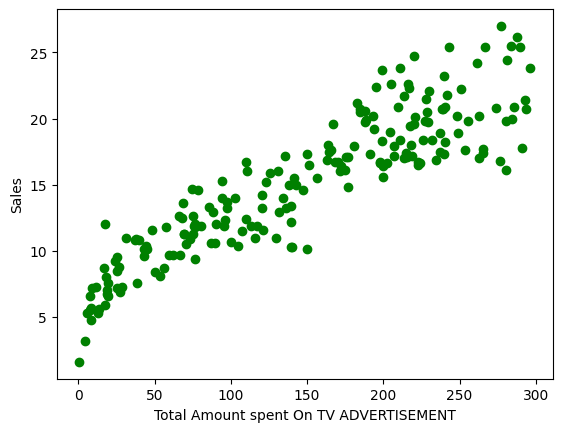

In [13]:
%matplotlib inline
plt.xlabel('Total Amount spent On TV ADVERTISEMENT') 
plt.ylabel('Sales') 
plt.scatter(df['TV'],df['Sales'],color='green')

In [14]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [15]:
X = df[['TV']]     # input feature

y = df['Sales']    # output

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
print("Slope =", model.coef_)

print("Intercept =", np.round(model.intercept_).astype(int))

Slope = [0.05548294]
Intercept = 7


In [72]:
y_pred = model.predict(X_test)
print(y_pred[:])
print( y_test[:5] )

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475  8.92396497  8.4817344
 18.2075123   8.06750728 12.64550975 14.93162809  8.12814594 17.89876565
 11.00880637 20.47832788 20.80631846 12.59883297 10.9051829  22.38854775
  9.41796094  7.92506736 20.83908497 13.81520938 10.77080925  7.92682509
 15.95947357 10.63490851 20.80292008 10.43434164 21.5784752  21.18364487
 12.12821771 22.80953262 12.60992766  6.46441252]
95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64


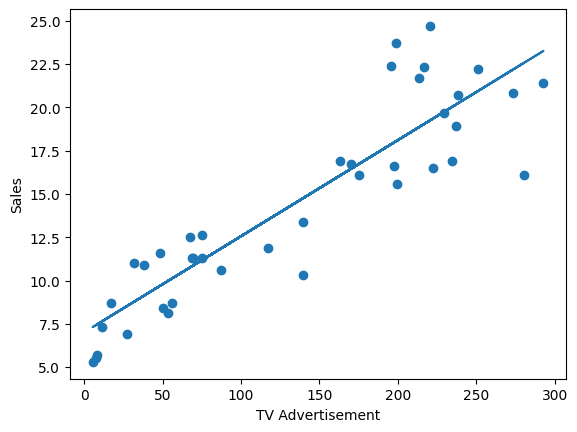

In [25]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("TV Advertisement")

plt.ylabel("Sales")

plt.show()

In [26]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

0.802561303423698


In [31]:
X2 = df[['TV','Radio', 'Newspaper'] ]     # input feature

y2 = df['Sales']

In [32]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
print("Slope =", np.round( model.coef_,3))

print("Intercept =",model.intercept_)

Slope = [0.055 0.101 0.004]
Intercept = 4.714126402214127


In [69]:
y_pred = model.predict(X_test)

print(y_pred[:5])      # predicted sales
print(y_test[:5])      # actual sales

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879]
95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64


In [38]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE =", mean_absolute_error(y_test,y_pred))
print("MSE =", mean_squared_error(y_test,y_pred))
print("R2 =", r2_score(y_test,y_pred))

MAE = 1.2748262109549338
MSE = 2.9077569102710896
R2 = 0.9059011844150826


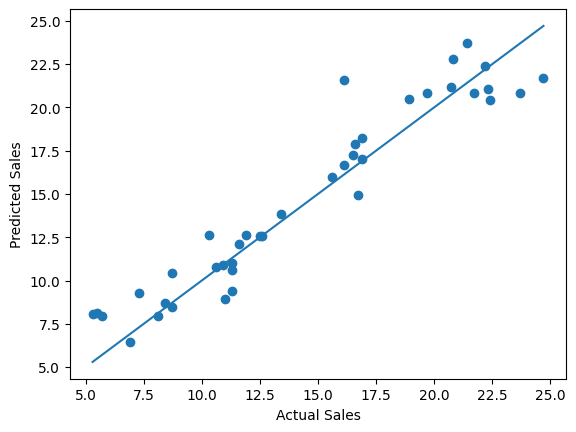

In [42]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)


plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

In [43]:
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("R2:", r2_score(y_test,y_pred))

MAE: 1.2748262109549338
MSE: 2.9077569102710896
R2: 0.9059011844150826


In [57]:
print(np.round(model.coef_,3))

[0.055 0.101 0.004]
